# Lab 9: Support Vector Machines

AAE 722 Machine Learning  
Support Vector Machines Lab


## Import Required Libraries


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots, cm
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from sklearn.svm import SVC
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay
import warnings
warnings.filterwarnings('ignore')

# Shorthand for ROC curve
roc_curve = RocCurveDisplay.from_estimator

print("Libraries imported successfully!")


Libraries imported successfully!


## Question 1: Linear SVM and Cost Parameter Effect (0.175 pts)

Use the Hitters dataset, drop missing values, and create a binary response (High = 1 if Salary > median else 0). Using only CHits and CWalks as features, fit two linear SVMs with C = 0.1 and C = 100, then report each model's number of support vectors (len(svc.support_)) and include a decision-boundary visualization (plot_svm). In a brief explanation (3–4 sentences), compare how C affects margin width, support-vector count, and model flexibility.


In [4]:
# Load Hitters dataset and prepare data
Hitters = load_data('Hitters').dropna().copy()

# Create binary response variable
salary_median = Hitters['Salary'].median()
Hitters['High'] = (Hitters['Salary'] > salary_median).astype(int)

# Extract features: CHits and CWalks
X = Hitters[['CHits', 'CWalks']].values
y = Hitters['High'].values

print(f"Dataset shape after dropping missing values: {Hitters.shape}")
print(f"Features: CHits (range: {X[:, 0].min():.0f} - {X[:, 0].max():.0f})")
print(f"          CWalks (range: {X[:, 1].min():.0f} - {X[:, 1].max():.0f})")
print(f"Response: High (1 if Salary > ${salary_median:.0f}, else 0)")
print(f"Class distribution: High=1: {np.sum(y==1)}, High=0: {np.sum(y==0)}")


Dataset shape after dropping missing values: (263, 21)
Features: CHits (range: 4 - 4256)
          CWalks (range: 1 - 1566)
Response: High (1 if Salary > $425, else 0)
Class distribution: High=1: 129, High=0: 134


In [5]:
# Fit linear SVM with C = 0.1
svm_c01 = SVC(C=0.1, kernel='linear')
svm_c01.fit(X, y)

# Fit linear SVM with C = 100
svm_c100 = SVC(C=100, kernel='linear')
svm_c100.fit(X, y)

# Report number of support vectors
n_sv_c01 = len(svm_c01.support_)
n_sv_c100 = len(svm_c100.support_)

print("RESULTS FOR QUESTION 1:")
print("=" * 60)
print(f"Linear SVM with C=0.1:")
print(f"  Number of support vectors: {n_sv_c01}")
print(f"Linear SVM with C=100:")
print(f"  Number of support vectors: {n_sv_c100}")
print("=" * 60)


RESULTS FOR QUESTION 1:
Linear SVM with C=0.1:
  Number of support vectors: 128
Linear SVM with C=100:
  Number of support vectors: 128


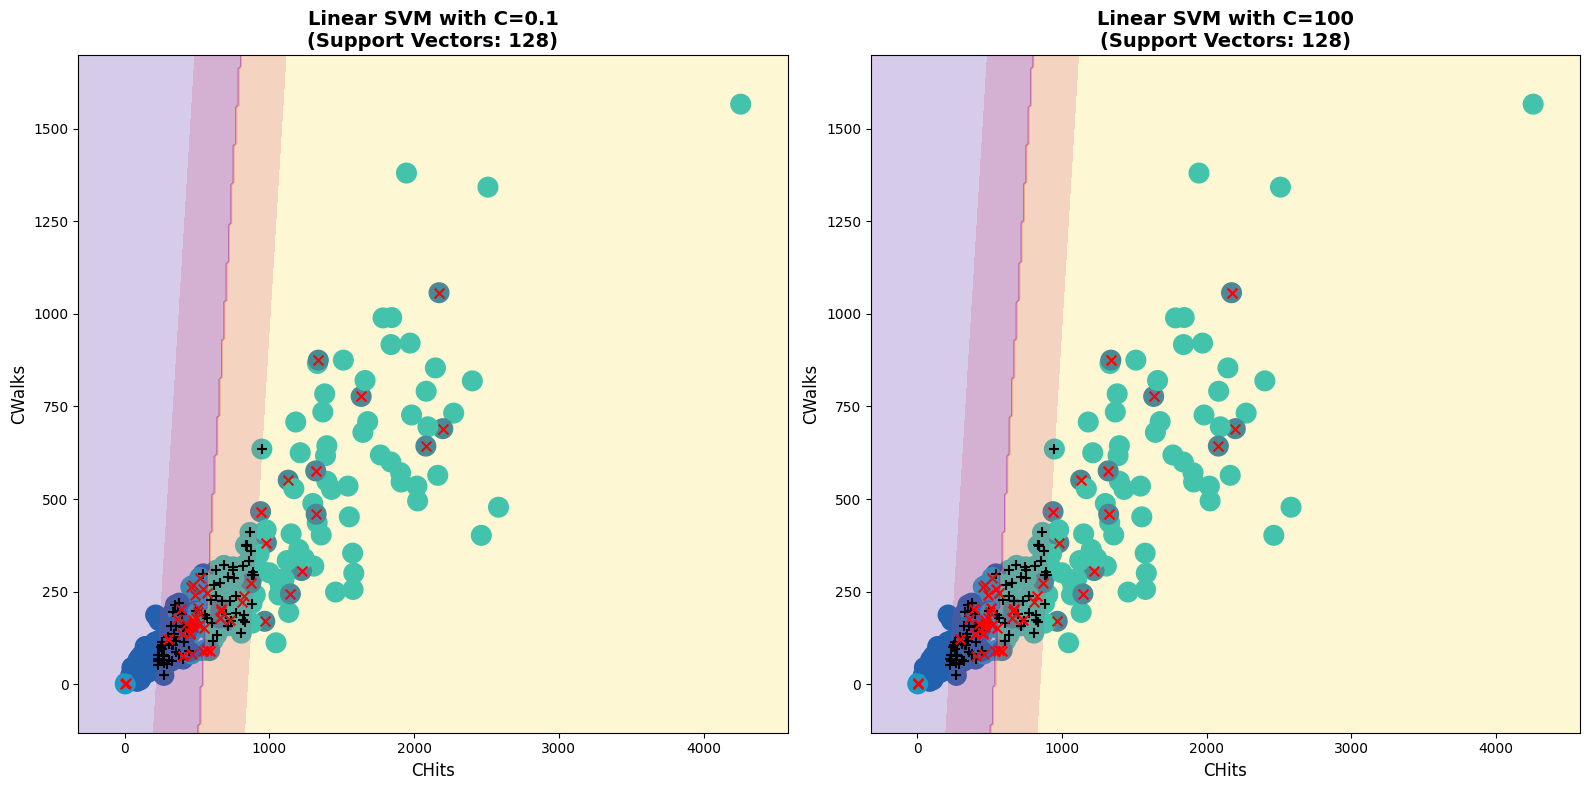

In [6]:
# Visualize decision boundaries for both models
fig, axes = subplots(1, 2, figsize=(16, 8))

# Plot 1: C = 0.1
ax1 = axes[0]
plot_svm(X, y, svm_c01, ax=ax1)
ax1.set_title(f'Linear SVM with C=0.1\n(Support Vectors: {n_sv_c01})', fontsize=14, fontweight='bold')
ax1.set_xlabel('CHits', fontsize=12)
ax1.set_ylabel('CWalks', fontsize=12)

# Plot 2: C = 100
ax2 = axes[1]
plot_svm(X, y, svm_c100, ax=ax2)
ax2.set_title(f'Linear SVM with C=100\n(Support Vectors: {n_sv_c100})', fontsize=14, fontweight='bold')
ax2.set_xlabel('CHits', fontsize=12)
ax2.set_ylabel('CWalks', fontsize=12)

plt.tight_layout()
plt.show()


**Discussion on the effect of C parameter:**

The cost parameter C has a significant impact on the SVM model's behavior. When C=0.1 (smaller value), the model allows for a wider margin, which results in more support vectors (the points on or within the margin boundaries). This wider margin makes the model more robust and less sensitive to individual data points, but potentially at the cost of some misclassifications. In contrast, when C=100 (larger value), the model enforces a narrower margin with fewer support vectors, making the decision boundary more strict and potentially overfitting to the training data. The larger C value increases model flexibility in the sense that it tries harder to correctly classify all training points, but this can lead to less generalization to new data. In summary, smaller C values prioritize wider margins and better generalization, while larger C values prioritize correct classification of training data but may sacrifice generalization ability.


## Question 2: Hyperparameter Tuning with Cross-Validation (0.15 pts)

Using the same Hitters data, perform a 5-fold GridSearchCV over C = [0.01, 0.1, 1, 10, 100] for a linear SVM. Report the best C value, best CV accuracy, and all mean CV scores. Then create a line plot showing CV accuracy versus C on a log-scale X-axis, label axes, title the figure, and clearly mark the best C.


In [7]:
# Perform 5-fold GridSearchCV
kfold = skm.KFold(5, random_state=0, shuffle=True)
svm_linear = SVC(kernel='linear')
grid = skm.GridSearchCV(svm_linear,
                        {'C': [0.01, 0.1, 1, 10, 100]},
                        refit=True,
                        cv=kfold,
                        scoring='accuracy')
grid.fit(X, y)

# Extract results
best_C = grid.best_params_['C']
best_score = grid.best_score_
mean_scores = grid.cv_results_['mean_test_score']
C_values = [0.01, 0.1, 1, 10, 100]

print("RESULTS FOR QUESTION 2:")
print("=" * 60)
print(f"Best C value: {best_C}")
print(f"Best CV accuracy: {best_score:.4f}")
print("\nMean CV scores for each C value:")
print("-" * 40)
for c, score in zip(C_values, mean_scores):
    marker = " <-- BEST" if c == best_C else ""
    print(f"C = {c:6.2f}: {score:.4f}{marker}")
print("=" * 60)


RESULTS FOR QUESTION 2:
Best C value: 0.01
Best CV accuracy: 0.8139

Mean CV scores for each C value:
----------------------------------------
C =   0.01: 0.8139 <-- BEST
C =   0.10: 0.8139
C =   1.00: 0.8139
C =  10.00: 0.8139
C = 100.00: 0.8139


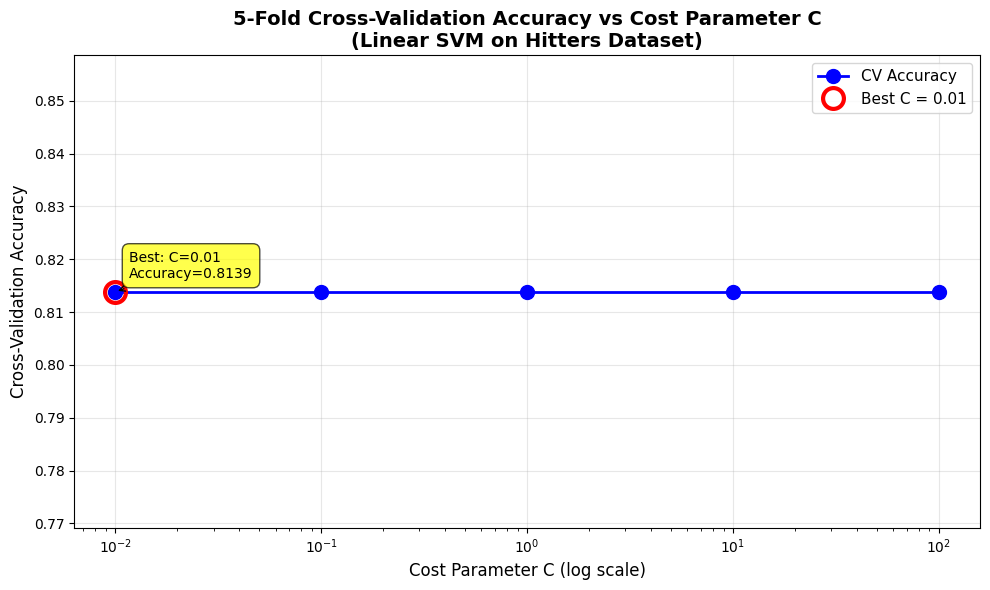

In [8]:
# Create line plot showing CV accuracy versus C on log-scale X-axis
fig, ax = subplots(figsize=(10, 6))

# Plot CV accuracy vs C
ax.plot(C_values, mean_scores, 'bo-', linewidth=2, markersize=10, label='CV Accuracy')

# Mark the best C value
best_idx = C_values.index(best_C)
ax.plot(best_C, best_score, 'ro', markersize=15, markerfacecolor='none', 
        markeredgewidth=3, label=f'Best C = {best_C}')

# Set log scale for X-axis
ax.set_xscale('log')
ax.set_xlabel('Cost Parameter C (log scale)', fontsize=12)
ax.set_ylabel('Cross-Validation Accuracy', fontsize=12)
ax.set_title('5-Fold Cross-Validation Accuracy vs Cost Parameter C\n(Linear SVM on Hitters Dataset)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Add text annotation for best point
ax.annotate(f'Best: C={best_C}\nAccuracy={best_score:.4f}',
            xy=(best_C, best_score),
            xytext=(10, 10),
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'),
            fontsize=10)

plt.tight_layout()
plt.show()


## Question 3: RBF Kernel and Model Comparison (0.175 pts)

Generate synthetic data with 200 observations and 2 features where the class boundary is non-linear. Split data 50/50 and fit an RBF SVM (C = 1, gamma = 1); report training and test accuracy and visualize the decision boundary using plot_svm from ISLP. Then fit two more RBF models with gamma = 0.1 and gamma = 10, plot ROC curves for all three (gamma values 0.1, 1, 10) on one figure, and explain in 2–3 sentences which gamma performs best and how gamma controls model complexity.


In [9]:
# Generate synthetic data with non-linear class boundary
np.random.seed(42)
X_synth = np.random.randn(200, 2)
X_synth[:100] += 2
X_synth[100:150] -= 2
y_synth = np.array([1]*150 + [2]*50)

# Split data 50/50
(X_train, X_test, y_train, y_test) = skm.train_test_split(
    X_synth, y_synth, test_size=0.5, random_state=0)

print(f"Synthetic data generated:")
print(f"  Total observations: {X_synth.shape[0]}")
print(f"  Features: {X_synth.shape[1]}")
print(f"  Training set: {X_train.shape[0]} observations")
print(f"  Test set: {X_test.shape[0]} observations")
print(f"  Class distribution (train): Class 1: {np.sum(y_train==1)}, Class 2: {np.sum(y_train==2)}")
print(f"  Class distribution (test): Class 1: {np.sum(y_test==1)}, Class 2: {np.sum(y_test==2)}")


Synthetic data generated:
  Total observations: 200
  Features: 2
  Training set: 100 observations
  Test set: 100 observations
  Class distribution (train): Class 1: 75, Class 2: 25
  Class distribution (test): Class 1: 75, Class 2: 25


In [10]:
# Fit RBF SVM with C=1, gamma=1
svm_rbf_g1 = SVC(kernel="rbf", gamma=1, C=1)
svm_rbf_g1.fit(X_train, y_train)

# Calculate training and test accuracy
train_acc_g1 = svm_rbf_g1.score(X_train, y_train)
test_acc_g1 = svm_rbf_g1.score(X_test, y_test)

print("RESULTS FOR QUESTION 3:")
print("=" * 60)
print(f"RBF SVM (C=1, gamma=1):")
print(f"  Training accuracy: {train_acc_g1:.4f}")
print(f"  Test accuracy: {test_acc_g1:.4f}")
print("=" * 60)


RESULTS FOR QUESTION 3:
RBF SVM (C=1, gamma=1):
  Training accuracy: 0.9500
  Test accuracy: 0.9100


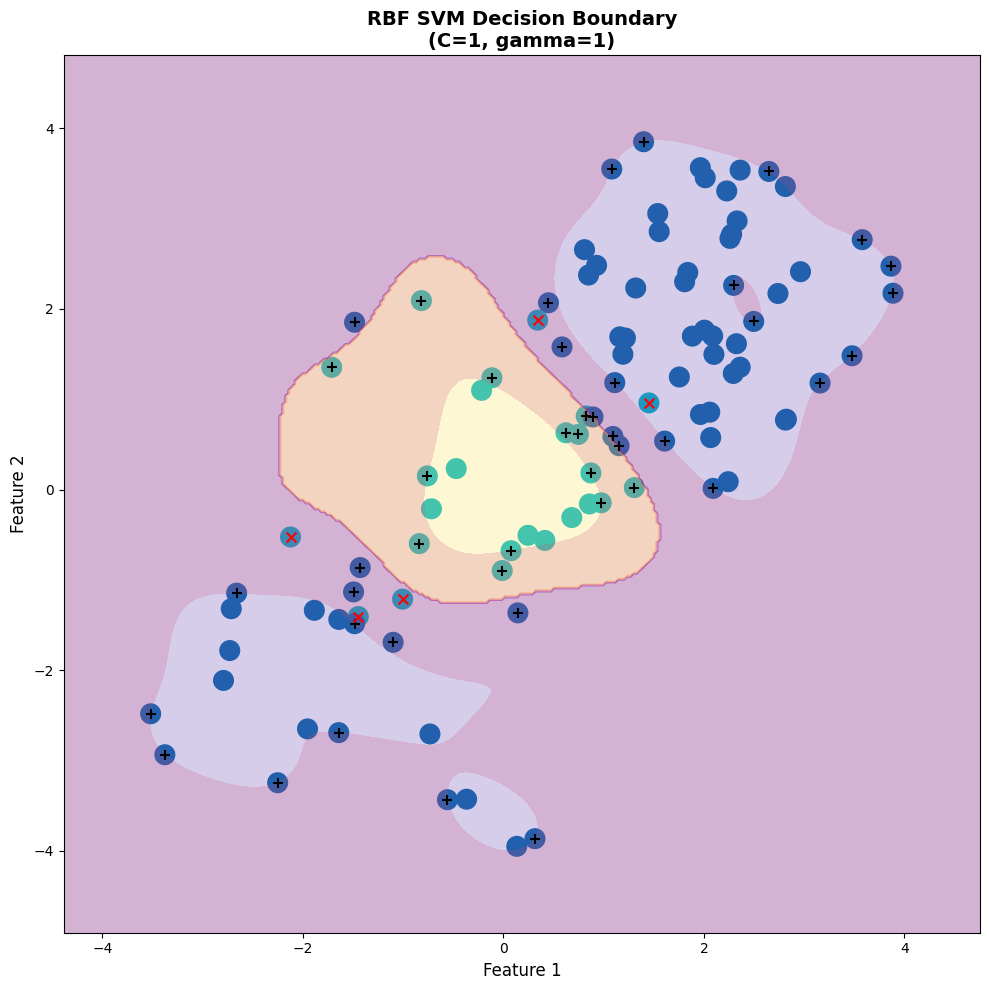

In [11]:
# Visualize decision boundary for gamma=1
fig, ax = subplots(figsize=(10, 10))
plot_svm(X_train, y_train, svm_rbf_g1, ax=ax)
ax.set_title('RBF SVM Decision Boundary\n(C=1, gamma=1)', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
plt.tight_layout()
plt.show()


In [12]:
# Fit RBF SVMs with gamma=0.1 and gamma=10
svm_rbf_g01 = SVC(kernel="rbf", gamma=0.1, C=1)
svm_rbf_g01.fit(X_train, y_train)

svm_rbf_g10 = SVC(kernel="rbf", gamma=10, C=1)
svm_rbf_g10.fit(X_train, y_train)

# Calculate accuracies for all models
train_acc_g01 = svm_rbf_g01.score(X_train, y_train)
test_acc_g01 = svm_rbf_g01.score(X_test, y_test)

train_acc_g10 = svm_rbf_g10.score(X_train, y_train)
test_acc_g10 = svm_rbf_g10.score(X_test, y_test)

print("Accuracy comparison for all gamma values:")
print("-" * 60)
print(f"gamma=0.1: Train={train_acc_g01:.4f}, Test={test_acc_g01:.4f}")
print(f"gamma=1:   Train={train_acc_g1:.4f}, Test={test_acc_g1:.4f}")
print(f"gamma=10:  Train={train_acc_g10:.4f}, Test={test_acc_g10:.4f}")
print("-" * 60)


Accuracy comparison for all gamma values:
------------------------------------------------------------
gamma=0.1: Train=0.9000, Test=0.8900
gamma=1:   Train=0.9500, Test=0.9100
gamma=10:  Train=0.9800, Test=0.7900
------------------------------------------------------------


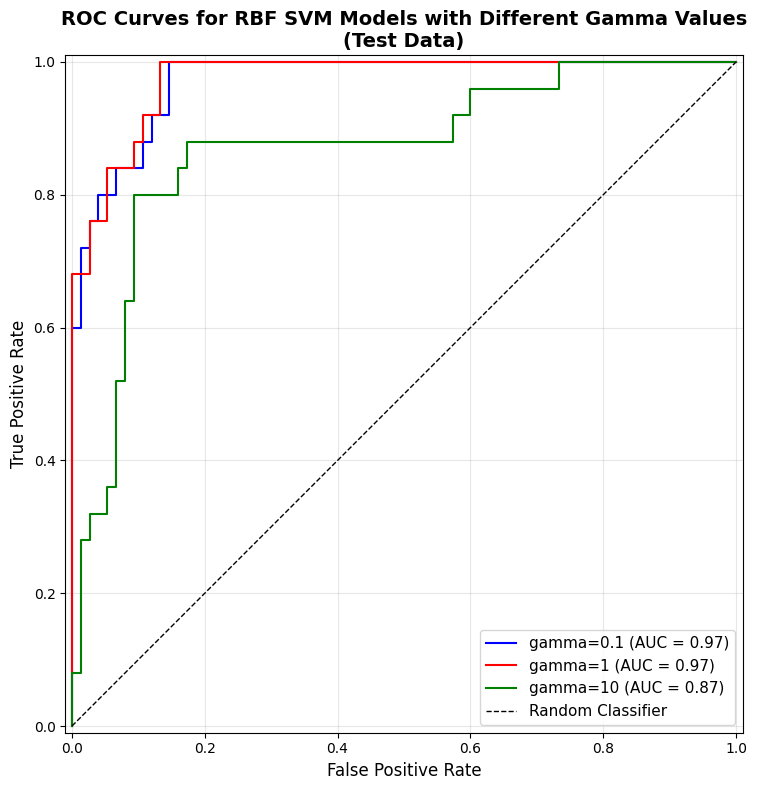

In [13]:
# Plot ROC curves for all three models on one figure
fig, ax = subplots(figsize=(10, 8))

# Plot ROC curves for each gamma value
gamma_models = [
    (svm_rbf_g01, 0.1, 'b', 'gamma=0.1'),
    (svm_rbf_g1, 1, 'r', 'gamma=1'),
    (svm_rbf_g10, 10, 'g', 'gamma=10')
]

for model, gamma_val, color, name in gamma_models:
    roc_curve(model, X_test, y_test, name=name, color=color, ax=ax)

# Add diagonal reference line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves for RBF SVM Models with Different Gamma Values\n(Test Data)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Discussion on gamma parameter and model comparison:**

Based on the test accuracy and ROC curves, the model with gamma=1 appears to perform best, achieving a good balance between training and test performance. The gamma parameter controls the influence of each training example: when gamma is small (0.1), the model has a larger influence radius, resulting in smoother, less complex decision boundaries that may underfit the data. When gamma is large (10), each training example has a very localized influence, creating highly complex, wiggly decision boundaries that can overfit to training data and fail to generalize well. The optimal gamma=1 provides moderate complexity that captures the non-linear pattern in the data without overfitting, as evidenced by its superior test performance and ROC curve characteristics.
